# ACCESSAI: First Proto

In [1]:
from ultralytics import YOLO
import torch
import os
import yaml
import requests

/home/JNB/anaconda3/envs/yoloEnv/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
print(f"¿GPU disponible? {torch.cuda.is_available()}")
print(f"Dispositivo: {torch.cuda.get_device_name(0)}")
print(f"Versión HIP: {torch.version.hip}")

¿GPU disponible? True
Dispositivo: AMD Radeon RX 9060 XT
Versión HIP: 7.13.99004


In [3]:
DATASET_PATH = "dataset"  # Ajusta si es necesario

# 1. Verificar la estructura de carpetas
print("Estructura del dataset:")
for split in ['train', 'valid', 'test']:
    split_path = os.path.join(DATASET_PATH, split)
    if os.path.exists(split_path):
        images_path = os.path.join(split_path, 'images')
        labels_path = os.path.join(split_path, 'labels')
        n_images = len(os.listdir(images_path)) if os.path.exists(images_path) else 0
        n_labels = len(os.listdir(labels_path)) if os.path.exists(labels_path) else 0
        print(f"  {split}: {n_images} imágenes, {n_labels} labels")
    else:
        print(f"  {split}: ❌ No existe")

# 2. Leer el data.yaml
yaml_path = os.path.join(DATASET_PATH, "data.yaml")
with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

print("\nContenido del data.yaml:")
print(f"  nc: {data_config.get('nc')}")
print(f"  names: {data_config.get('names')}")
print(f"  train: {data_config.get('train')}")
print(f"  val: {data_config.get('val')}")
print(f"  test: {data_config.get('test')}")

Estructura del dataset:
  train: 19186 imágenes, 19186 labels
  valid: 3511 imágenes, 3511 labels
  test: 1629 imágenes, 1629 labels

Contenido del data.yaml:
  nc: 25
  names: ['Bike', 'Building', 'Car', 'Person', 'Stairs', 'Traffic sign', 'Electrical Pole', 'Road', 'Motorcycle', 'Dustbin', 'Dog', 'Manhole', 'Tree', 'Guard rail', 'Pedestrian crosswalk', 'Truck', 'Bus', 'Bench', 'Traffic Cone', 'Fire hydrant', 'Teraffic Barrel', 'Plant Pot', 'Electrical Box', 'Chair', 'Bicycle Rack']
  train: ../train/images
  val: ../valid/images
  test: ../test/images


#### IMPORTANTE: Habrá que reducir el número de clases y seleccionar aquellas que consideremos más importantes para la detección de barreras de accesibilidad urbana. También habrá que compensar el desbalance entre las clases seleccionadas si este existiera.

In [4]:
# Descarga del modelo preentrenado y escaneado del conjunto de validación del dataset.
!yolo val model=yolo26n.pt data=dataset/data.yaml

Ultralytics 8.4.157 🚀 Python-3.11.16 torch-2.11.0+rocm7.13.0 CUDA:0 (AMD Radeon RX 9060 XT, 16304MiB)
YOLO26n summary (fused): 120 layers, 2,408,932 parameters, 0 gradients, 5.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 190.4±73.9 MB/s, size: 85.2 KB)
val: Scanning /home/JNB/Sync/PythonAI&ML/ProyectoAI/dataset/valid/labels.cache... 3511 images, 11 backgrounds, 8 corrupt: 100% ━━━━━━━━━━━━ 3511/3511 1.6Git/s 0.0s
val: /home/JNB/Sync/PythonAI&ML/ProyectoAI/dataset/valid/images/IMG_21548.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /home/JNB/Sync/PythonAI&ML/ProyectoAI/dataset/valid/images/IMG_24200.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /home/JNB/Sync/PythonAI&ML/ProyectoAI/dataset/valid/images/IMG_24203.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /home/JNB/Sync/PythonAI&ML/ProyectoAI/dataset/valid/images/IMG_24204.jpg: ignoring corrupt image/label: labels mix segment 

#### mAP: mean Average Precision, métrica estándar para evaluar modelos de detección de objetos, que mide cuán bueno es el modelo detectando objetos y localizándolos correctamente. maP50 a 0.0333, MUY BAJO, el modelo intenta detectar las clases de nuestro dataset pero solo conoce las clases mediante las que ha sido entrenado

In [5]:
model = YOLO("yolo26n.pt")

In [6]:
# Entenamiento base del modelo, punto de partida:

results = model.train(
    data="dataset/data.yaml",
    epochs=50,          
    imgsz=640,          
    batch=16,
    device=0    # Activa la GPU
)

Ultralytics 8.4.157 🚀 Python-3.11.16 torch-2.11.0+rocm7.13.0 CUDA:0 (AMD Radeon RX 9060 XT, 16304MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=None, opset=None, o

MIOpen(HIP): Warning [ParseAndLoadDb] File is unreadable: "/home/JNB/anaconda3/envs/yoloEnv/lib/python3.11/site-packages/_rocm_sdk_libraries_gfx120X_all/share/miopen/db/gfx1200_16.HIP.fdb.txt"


AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 117.9±44.4 MB/s, size: 56.1 KB)
train: Scanning /home/JNB/Sync/PythonAI&ML/ProyectoAI/dataset/train/labels.cache... 19186 images, 83 backgrounds, 24 corrupt: 100% ━━━━━━━━━━━━ 19186/19186 8.0Git/s 0.0s
train: /home/JNB/Sync/PythonAI&ML/ProyectoAI/dataset/train/images/IMG_02971.jpg: ignoring corrupt image/label: labels mix segment and detection rows
train: /home/JNB/Sync/PythonAI&ML/ProyectoAI/dataset/train/images/IMG_04893.jpg: ignoring corrupt image/label: labels mix segment and detection rows
train: /home/JNB/Sync/PythonAI&ML/ProyectoAI/dataset/train/images/IMG_06171.jpg: ignoring corrupt image/label: labels mix segment and detection rows
train: /home/JNB/Sync/PythonAI&ML/ProyectoAI/dataset/train/images/IMG_06873.jpg: ignoring corrupt image/label: labels mix segment and detection rows
train: /home/JNB/Sync/PythonAI&ML/ProyectoAI/dataset/train/images/IMG_06874.jpg: ignoring corrupt image/label: labels mix segment

a_grid_desc_m_ak_container_{25600, 128}
b_grid_desc_n_bk_container_{192, 128}
e_grid_desc_mblock_mperblock_nblock_nperblock_container_{25600, 192}
a_grid_desc_m_ak_container_{25600, 128}
b_grid_desc_n_bk_container_{192, 128}
e_grid_desc_mblock_mperblock_nblock_nperblock_container_{25600, 192}
a_grid_desc_m_ak_container_{25600, 128}
b_grid_desc_n_bk_container_{192, 128}
e_grid_desc_mblock_mperblock_nblock_nperblock_container_{25600, 192}
a_grid_desc_m_ak_container_{25600, 128}
b_grid_desc_n_bk_container_{192, 128}
e_grid_desc_mblock_mperblock_nblock_nperblock_container_{25600, 192}
a_grid_desc_m_ak_container_{25600, 128}
b_grid_desc_n_bk_container_{192, 128}
e_grid_desc_mblock_mperblock_nblock_nperblock_container_{25600, 192}
a_grid_desc_m_ak_container_{25600, 128}
b_grid_desc_n_bk_container_{192, 128}
e_grid_desc_mblock_mperblock_nblock_nperblock_container_{25600, 192}
a_grid_desc_m_ak_container_{25600, 128}
b_grid_desc_n_bk_container_{192, 128}
e_grid_desc_mblock_mperblock_nblock_nper

### Métricas del entrenamiento

Durante el entrenamiento, Ultralytics muestra una serie de métricas que reflejan el rendimiento del modelo. Estas son las más importantes:

#### Pérdidas (Losses)

| Métrica | ¿Qué mide? | ¿Qué esperar? |
| :--- | :--- | :--- |
| **box_loss** | Error en la localización de las bounding boxes (coordenadas). | Debe bajar con las épocas. |
| **cls_loss** | Error en la clasificación de cada objeto (¿es un coche? ¿una persona?). | Debe bajar con las épocas. |
| **l1_loss** | Pérdida auxiliar de regresión que ayuda a estabilizar el entrenamiento. | Debe bajar con las épocas. |

#### Métricas de evaluación (Box)

| Métrica | ¿Qué mide? | ¿Qué esperar? |
| :--- | :--- | :--- |
| **Precision (P)** | De todos los objetos que el modelo detecta, ¿cuántos son correctos? | Cuanto más alto, mejor. Cercano a 1.0 es ideal. |
| **Recall (R)** | De todos los objetos reales, ¿cuántos detecta el modelo? | Cuanto más alto, mejor. Cercano a 1.0 es ideal. |
| **mAP50** | Precisión media con un umbral de solapamiento (IoU) del 50%. | Cuanto más alto, mejor. >0.90 es excelente. |
| **mAP50-95** | Precisión media promediada sobre umbrales de IoU de 50% a 95%. | Cuanto más alto, mejor. >0.70 es muy bueno. |

#### Otras métricas

| Métrica | ¿Qué mide? |
| :--- | :--- |
| **Instances** | Número de objetos anotados en el batch actual. |
| **GPU_mem** | Memoria de la GPU utilizada durante el entrenamiento. |
| **Size** | Tamaño de las imágenes de entrada (ej. 640x640). |

#### ¿Qué es el IoU?

El **IoU** (Intersection over Union) mide el solapamiento entre la bounding box predicha y la real. Va de 0 (sin solapamiento) a 1 (solapamiento perfecto). Un IoU de 0.5 significa que la predicción cubre al menos el 50% del objeto real.

#### ¿Qué es el mAP?

El **mAP** (mean Average Precision) es la métrica estándar para evaluar modelos de detección de objetos. Combina Precision y Recall en un solo número. Un mAP alto significa que el modelo detecta los objetos correctamente y con buena localización.

Si el mAP es bueno (>0.90) → Documentar y pasar a la demo.

Si el mAP es bajo (<0.80) → Analizar qué clases fallan y considerar:

    Más épocas.

    Data augmentation específico.

    Ajuste de hiperparámetros con model.tune().

Si la demo falla mucho → Documentar la limitación de dominio y proponer fine-tuning con imágenes locales como trabajo futuro.

In [9]:
model = YOLO("runs/detect/train-2/weights/best.pt")  # Cargamos el mejor modelo

In [10]:
metrics = model.val(data="dataset/data.yaml", split="test")  # Evaluamos

Ultralytics 8.4.157 🚀 Python-3.11.16 torch-2.11.0+rocm7.13.0 CUDA:0 (AMD Radeon RX 9060 XT, 16304MiB)
YOLO26n summary (fused): 120 layers, 2,379,711 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 160.4±114.2 MB/s, size: 52.5 KB)
val: Scanning /home/JNB/Sync/PythonAI&ML/ProyectoAI/dataset/test/labels... 1629 images, 5 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 1629/1629 4.9Kit/s 0.3s0.0s
val: /home/JNB/Sync/PythonAI&ML/ProyectoAI/dataset/test/images/IMG_20781.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: New cache created: /home/JNB/Sync/PythonAI&ML/ProyectoAI/dataset/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 414, len(boxes) = 2370. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          

In [11]:
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")

mAP50: 0.9233
mAP50-95: 0.7766
Precision: 0.9016
Recall: 0.8929


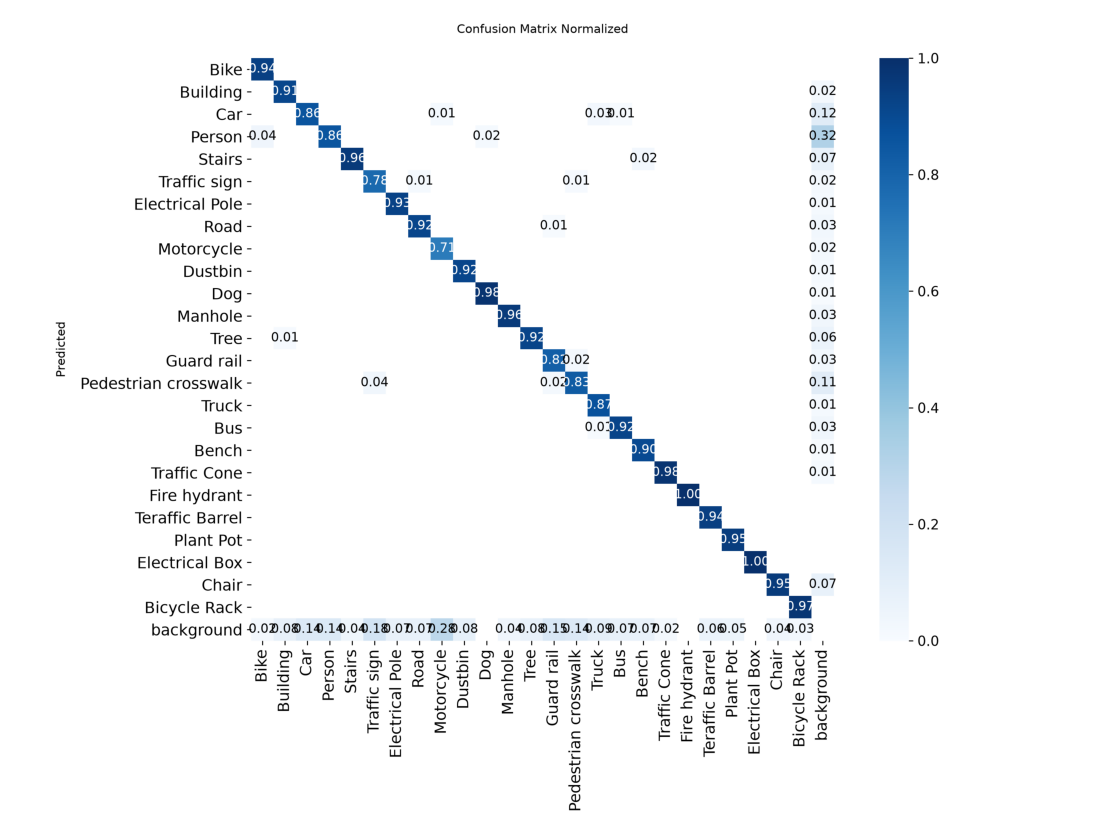

In [13]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("runs/detect/train-2/confusion_matrix_normalized.png")  # Matriz de confusión normalizada
plt.figure(figsize=(14, 12))
plt.imshow(img)
plt.axis('off')
plt.show()